In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [81]:
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("C:/Users/admin/Downloads/zomato.csv",encoding='latin-1')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Basic information about dataset

In [82]:
print(df.shape)

(9551, 21)


In [83]:
print(df.columns)


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [84]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [85]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### 1.Handling Missing values
### 2.explore about the numerical variables
### 3.explore about categorical variables
### 4.Finding Relationship between features

In [86]:
null_columns = df.columns[df.isnull().any()].tolist()
null_columns

['Cuisines']

In [87]:
df["Cuisines"].isnull().sum()


np.int64(9)

In [88]:
df["Cuisines"]= df["Cuisines"].fillna(df['Cuisines'].mode()[0])


In [89]:
df["Cuisines"].isnull().sum()

np.int64(0)

#### import country code with country name dataset


In [90]:
df_country=pd.read_excel("C:/Users/admin/Downloads/country_code.xlsx")
df_country.head()

,Country Code,Country
0,1,India
1,14,Australia
2,30,Brazil
3,37,Canada
4,94,Indonesia


#### merge both datsets

In [91]:
final_df = pd.merge(df,df_country,on='Country Code',how='left')
final_df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Phillipines


In [92]:
##To check Data Types
final_df.dtypes


Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
Country                  object
dtype: object

In [93]:
final_df.Country.value_counts()

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
South Africa        60
UAE                 60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Qatar               20
Singapore           20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

In [94]:
country_names=final_df.Country.value_counts().index ##country names

In [95]:
country_val=final_df.Country.value_counts().values

### pie chart for top 3 countries that uses zomato

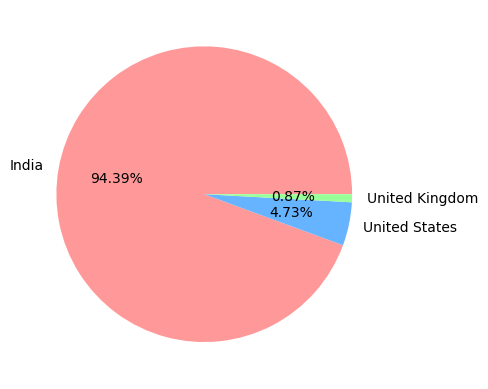

In [96]:
colors = ['#ff9999','#66b3ff','#99ff99',"#c2f0c2","#a3a3c2"]  
plt.pie(country_val[:3],labels=country_names[:3],autopct="%1.2f%%",colors=colors)
plt.show()

#### Observation:  Zomato maximum records or transaction are from India .After that USA and then United Kingdoms

In [97]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [98]:
final_df.groupby(['Aggregate rating','Rating color','Rating text']).size()

Aggregate rating  Rating color  Rating text
0.0               White         Not rated      2148
1.8               Red           Poor              1
1.9               Red           Poor              2
2.0               Red           Poor              7
2.1               Red           Poor             15
2.2               Red           Poor             27
2.3               Red           Poor             47
2.4               Red           Poor             87
2.5               Orange        Average         110
2.6               Orange        Average         191
2.7               Orange        Average         250
2.8               Orange        Average         315
2.9               Orange        Average         381
3.0               Orange        Average         468
3.1               Orange        Average         519
3.2               Orange        Average         522
3.3               Orange        Average         483
3.4               Orange        Average         498
3.5               Ye

In [99]:
ratings=final_df.groupby(['Aggregate rating','Rating color','Rating text']).size().reset_index().rename(columns={0:'Rating Count'})

In [100]:
ratings

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15
5,2.2,Red,Poor,27
6,2.3,Red,Poor,47
7,2.4,Red,Poor,87
8,2.5,Orange,Average,110
9,2.6,Orange,Average,191


### OBSEVATIONS:
#### 1.when rating are between 4.5 to 4.9--> Excellent
#### 2.when rating are between 4.0 to 4.4--> very good
#### 3.when rating are between 3.5 to 3.9--> Good
#### 4.when rating are between 2.5 to 3.4--> Average
#### 5.when rating are between 1.5 to 2.4--> Poor
#### 6.When rating are 0.0 --> Not rating



In [101]:
ratings.head()

,Aggregate rating,Rating color,Rating text,Rating Count
0,0.0,White,Not rated,2148
1,1.8,Red,Poor,1
2,1.9,Red,Poor,2
3,2.0,Red,Poor,7
4,2.1,Red,Poor,15


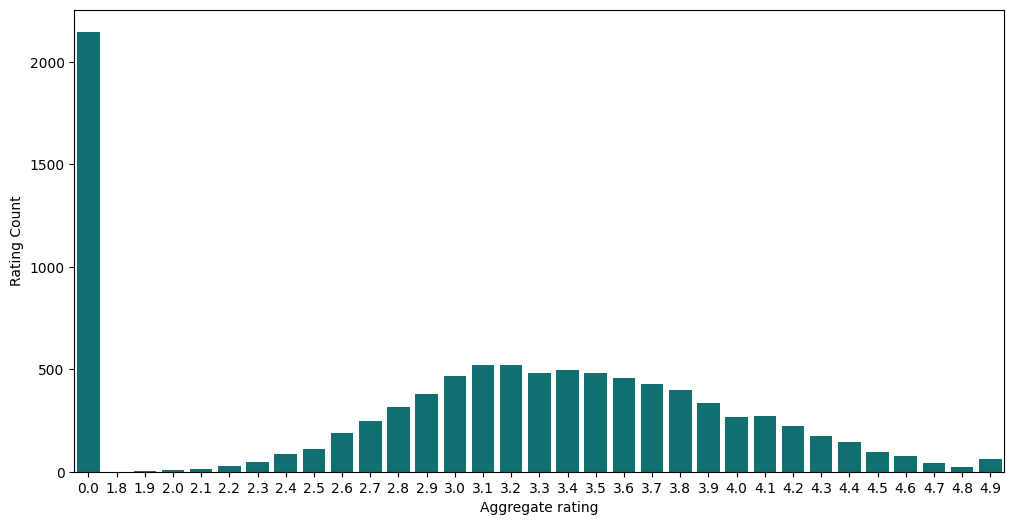

In [102]:
import matplotlib
plt.figure(figsize=(12, 6))
sns.barplot(x="Aggregate rating",y="Rating Count",data=ratings,color="teal")
plt.show()

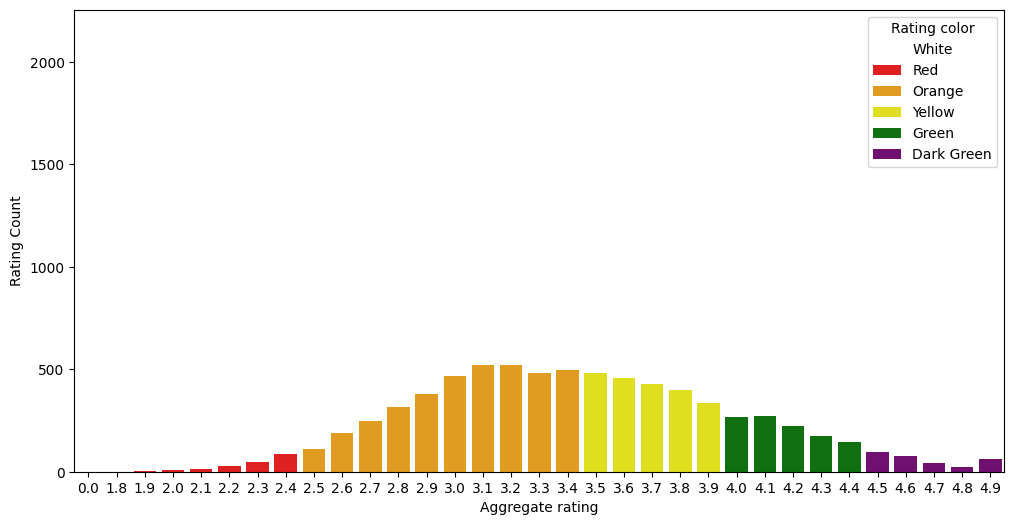

In [103]:
plt.figure(figsize=(12,6))
sns.barplot(x="Aggregate rating",y="Rating Count",hue='Rating color',data=ratings,palette=["White","Red","Orange","Yellow","Green","purple"])
plt.show()

### OBSEVATION:
#### 1.Not rated count is very high.
#### 2.maximum number of rating are between 3.0 to 3.7


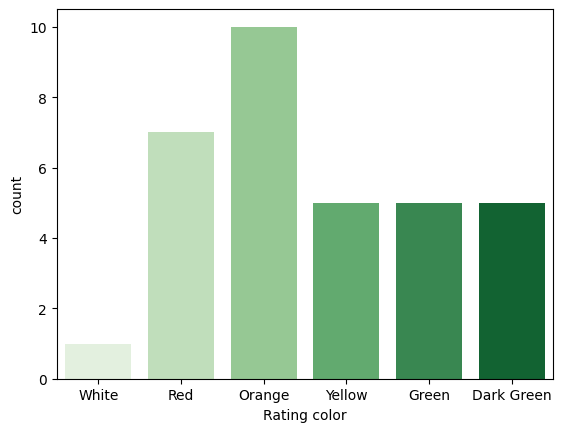

In [104]:
## COUNT PLOT
sns.countplot(x="Rating color",data=ratings,palette="Greens")
plt.show()

In [105]:
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [106]:
## Find  the countries name that has given 0 ratings....
final_df[final_df['Rating color']=='White'].groupby('Country').size().reset_index()

,Country,0
0,Brazil,5
1,India,2139
2,United Kingdom,1
3,United States,3


### OBSEVATION:-Maximum number of 0 ratings are from Indian customers


In [107]:
##Find out which currency is used by which country...
final_df.columns


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [108]:
final_df[['Country','Currency']].groupby(['Country','Currency']).size().reset_index()

,Country,Currency,0
0,Australia,Dollar($),24
1,Brazil,Brazilian Real(R$),60
2,Canada,Dollar($),4
3,India,Indian Rupees(Rs.),8652
4,Indonesia,Indonesian Rupiah(IDR),21
5,New Zealand,NewZealand($),40
6,Phillipines,Botswana Pula(P),22
7,Qatar,Qatari Rial(QR),20
8,Singapore,Dollar($),20
9,South Africa,Rand(R),60


In [109]:
##Which countries do have online deliveries options...
final_df[final_df['Has Online delivery'] == "Yes"].Country.value_counts()


Country
India    2423
UAE        28
Name: count, dtype: int64

In [110]:
final_df[['Has Online delivery','Country']].groupby(['Has Online delivery','Country']).size().reset_index()

,Has Online delivery,Country,0
0,No,Australia,24
1,No,Brazil,60
2,No,Canada,4
3,No,India,6229
4,No,Indonesia,21
5,No,New Zealand,40
6,No,Phillipines,22
7,No,Qatar,20
8,No,Singapore,20
9,No,South Africa,60


### OBSERVATION:-Online Deliveries are available in India and UAE

In [111]:
final_df[final_df["Has Table booking"] == "Yes"].Country.value_counts()


Country
India             1111
UAE                 18
Phillipines         14
United Kingdom      12
South Africa         2
Qatar                1
Name: count, dtype: int64

In [112]:
final_df[["Has Table booking",'Country']].groupby(['Has Table booking','Country']).size().reset_index()

,Has Table booking,Country,0
0,No,Australia,24
1,No,Brazil,60
2,No,Canada,4
3,No,India,7541
4,No,Indonesia,21
5,No,New Zealand,40
6,No,Phillipines,8
7,No,Qatar,19
8,No,Singapore,20
9,No,South Africa,58


#### OBSERVATION:-Table booking are available in India,Phillipines,Qatar,South AfricaUAE,United Kingdom


##### Create a pie chart for top 5 cities distribution...

In [113]:
final_df.City.value_counts().index


Index(['New Delhi', 'Gurgaon', 'Noida', 'Faridabad', 'Ghaziabad',
       'Bhubaneshwar', 'Lucknow', 'Ahmedabad', 'Amritsar', 'Guwahati',
       ...
       'Forrest', 'East Ballina', 'Huskisson', 'Inverloch', 'Lakeview',
       'Lakes Entrance', 'Mohali', 'Panchkula', 'Bandung', 'Randburg'],
      dtype='object', name='City', length=141)

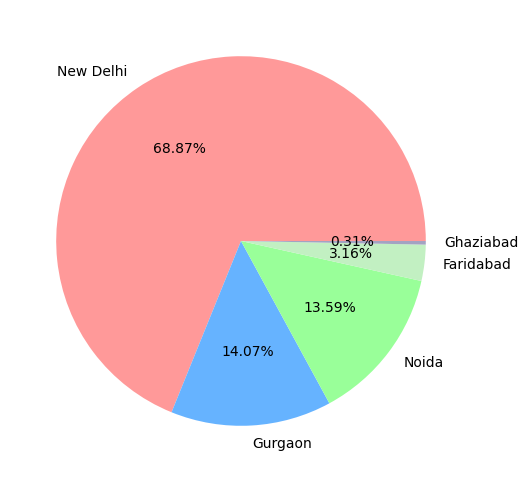

In [114]:
plt.figure(figsize=(8,6))
city_values=final_df.City.value_counts().values
city_labels=final_df.City.value_counts().index
colors = ['#ff9999','#66b3ff','#99ff99',"#c2f0c2","#a3a3c2"]  
plt.pie(city_values[:5],labels=city_labels[:5],autopct='%1.2f%%',colors=colors)
plt.show()

### Observation:-
#### New Delhi , Gurgaon , Noida , Faridabad and Ghaziabad are the top 5 cities by orders.

In [115]:

#Find the top 10 cuisines(food items)
final_df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes', 'Country'],
      dtype='object')

In [116]:
final_df.value_counts('Cuisines').index


Index(['North Indian', 'North Indian, Chinese', 'Chinese', 'Fast Food',
       'North Indian, Mughlai', 'Cafe', 'Bakery',
       'North Indian, Mughlai, Chinese', 'Bakery, Desserts', 'Street Food',
       ...
       'Chinese, North Indian, Italian, Continental, Fast Food',
       'Chinese, North Indian, Italian, Fast Food',
       'Tibetan, South Indian, North Indian', 'Tibetan, Street Food',
       'Turkish Pizza', 'Turkish, Arabian, Middle Eastern',
       'Turkish, Arabian, Moroccan, Lebanese',
       'Turkish, Mediterranean, Middle Eastern', 'Vietnamese, Fish and Chips',
       'Western, Asian, Cafe'],
      dtype='object', name='Cuisines', length=1825)

In [117]:
final_df.value_counts('Cuisines').values


array([945, 511, 354, ...,   1,   1,   1])

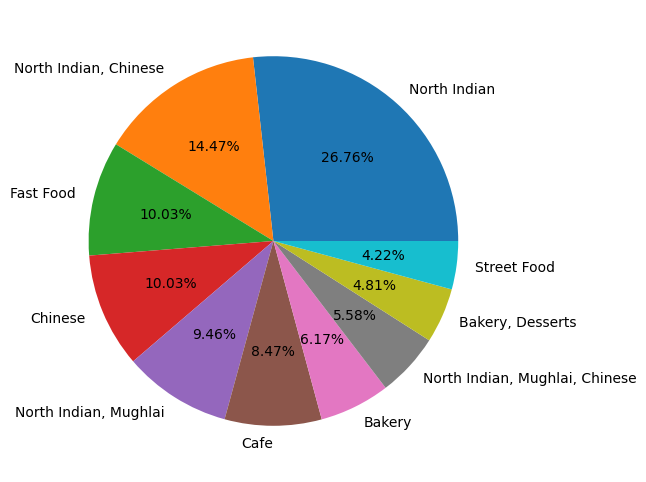

In [118]:
plt.figure(figsize=(8,6))
Cuisines_values=final_df.Cuisines.value_counts().values
Cuisines_labels=final_df.Cuisines.value_counts().index
plt.pie(Cuisines_values[:10],labels=Cuisines_labels[:10],autopct='%1.2f%%')
plt.show()

In [119]:
# Filter to include only restaurants with a significant number of votes (e.g., >100)
popular_restaurants = final_df[final_df['Votes'] > 100]

# Sort by Rating (descending) and then by Votes (descending)
top_restaurants = popular_restaurants.sort_values(by=['Aggregate rating', 'Votes'], ascending=False)

# Select important columns to view
top_10 = top_restaurants[['Restaurant Name', 'Cuisines', 'City', 'Aggregate rating', 'Votes']].head(10)
top_10


,Restaurant Name,Cuisines,City,Aggregate rating,Votes
2414,Barbeque Nation,"North Indian, Chinese",Kolkata,4.9,5966
2307,AB's - Absolute Barbecues,"European, Mediterranean, North Indian",Hyderabad,4.9,5434
2495,Mirchi And Mime,"North Indian, South Indian, Mughlai",Mumbai,4.9,3244
3013,Naturals Ice Cream,Ice Cream,New Delhi,4.9,2620
374,McGuire's Irish Pub & Brewery,"Burger, Bar Food, Steak",Pensacola,4.9,2238
9296,Talaga Sampireun,"Sunda, Indonesian",Tangerang,4.9,2212
3601,Indian Accent - The Manor,Modern Indian,New Delhi,4.9,1934
2409,Barbeque Nation,"North Indian, Chinese",Kolkata,4.9,1753
9279,Talaga Sampireun,"Sunda, Indonesian",Jakarta,4.9,1662
9291,Talaga Sampireun,"Sunda, Indonesian",Jakarta,4.9,1640


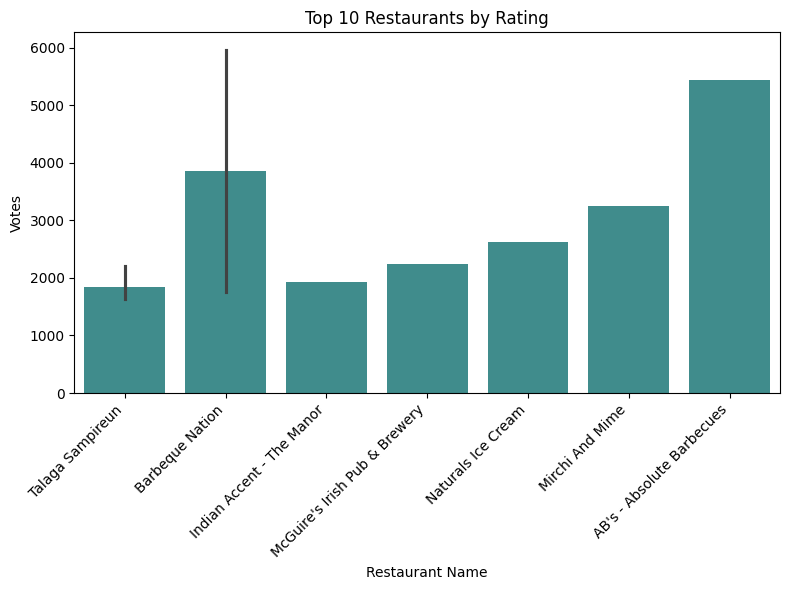

In [120]:
# Sort top_10 DataFrame by rating
top_10_sorted = top_10.sort_values(by='Votes', ascending=True)

# Create a bar plot
plt.figure(figsize=(8,6))
sns.barplot(
    x="Restaurant Name",
    y="Votes",
    data=top_10_sorted,
    color="teal",alpha=0.8
)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Restaurants by Rating")
plt.xlabel("Restaurant Name")
plt.ylabel("Votes")
plt.tight_layout()
plt.show()


In [121]:
df.head(2)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591


<Axes: >

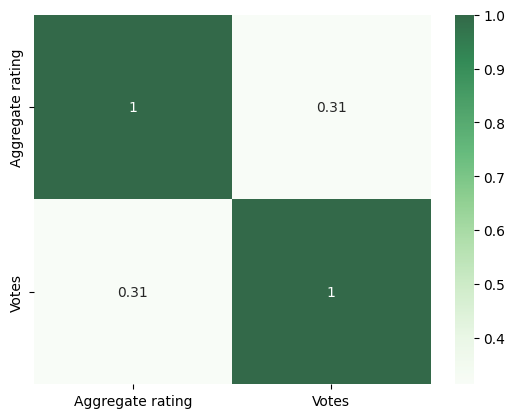

In [122]:
corr_matrix = df[["Aggregate rating", "Votes"]].corr()
sns.heatmap(corr_matrix,annot=True,cmap="Greens",alpha=0.8)


### Observation
#### Restaurants with more votes tend to have higher ratings.